In [1]:
!wget https://prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com/bv2hvm4pmz-3.zip
!unzip /content/bv2hvm4pmz-3.zip

--2024-12-11 12:21:28--  https://prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com/bv2hvm4pmz-3.zip
Resolving prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com (prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com)... 52.218.44.18, 52.218.61.120, 52.218.31.24, ...
Connecting to prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com (prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com)|52.218.44.18|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1340049458 (1.2G) [application/zip]
Saving to: ‘bv2hvm4pmz-3.zip’

bv2hvm4pmz-3.zip    100%[===================>]   1.25G  14.1MB/s    in 1m 42s  

2024-12-11 12:23:12 (12.5 MB/s) - ‘bv2hvm4pmz-3.zip’ saved [1340049458/1340049458]

Archive:  /content/bv2hvm4pmz-3.zip
  inflating: Indoor Air Quality Monitoring @ Brindisi Airport/complete_measure_node_airport_gold.csv  
  inflating: Indoor Air Quality Monitoring @ Brindisi Airport/complete_measure_node_airport_silver.csv  
  inflati

In [73]:
import pandas as pd

#taking chunks of data instead of all at once to evade memory problems
chunk_size = 50000
chunks = []

for filename in ["Indoor Air Quality Monitoring @ Brindisi Airport/complete_measure_node_airport_brown.csv",
                 "Indoor Air Quality Monitoring @ Brindisi Airport/complete_measure_node_airport_silver.csv",
                 "Indoor Air Quality Monitoring @ Brindisi Airport/complete_measure_node_airport_gold.csv"]:
    chunk_iter = pd.read_csv(filename, delimiter=';', chunksize=chunk_size)
    for chunk in chunk_iter:
        chunks.append(chunk)

df = pd.concat(chunks, ignore_index=True)

In [74]:
#turning null values into 0s
columns_to_fill = [
    'sps30_pm05_count', 'sps30_pm1_count', 'sps30_pm25_count', 'sps30_pm4_count',
    'sps30_pm10_count', 'sps30_pm_typ', 'sps30_pm25_ug', 'sps30_pm4_ug', 'sps30_pm10_ug'
]

df[columns_to_fill] = df[columns_to_fill].fillna(0)

print(df.isnull().sum())

id_measure          0
node_id             0
ads1115_value       0
ads1115_voltage     0
scd30_co2           0
scd30_temp          0
scd30_hum           0
sps30_pm05_count    0
sps30_pm1_count     0
sps30_pm1_ug        1
sps30_pm25_count    0
sps30_pm25_ug       0
sps30_pm4_count     0
sps30_pm4_ug        0
sps30_pm10_count    0
sps30_pm10_ug       0
sps30_pm_typ        0
ts_insertion        0
dtype: int64


In [75]:
df['brown'] = (df['node_id'] == 'node-air-brown').astype(int)
df['gold'] = (df['node_id'] == 'node-air-gold').astype(int)
df['silver'] = (df['node_id'] == 'node-air-silver').astype(int)

df = df.drop(columns=['id_measure'])
df = df.drop(columns=['node_id'])

df['ts_insertion'] = pd.to_datetime(df['ts_insertion'])

int_cols = df.select_dtypes(include=['int64']).columns
df[int_cols] = df[int_cols].astype('float64')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28177936 entries, 0 to 28177935
Data columns (total 19 columns):
 #   Column            Dtype         
---  ------            -----         
 0   ads1115_value     float64       
 1   ads1115_voltage   float64       
 2   scd30_co2         float64       
 3   scd30_temp        float64       
 4   scd30_hum         float64       
 5   sps30_pm05_count  float64       
 6   sps30_pm1_count   float64       
 7   sps30_pm1_ug      float64       
 8   sps30_pm25_count  float64       
 9   sps30_pm25_ug     float64       
 10  sps30_pm4_count   float64       
 11  sps30_pm4_ug      float64       
 12  sps30_pm10_count  float64       
 13  sps30_pm10_ug     float64       
 14  sps30_pm_typ      float64       
 15  ts_insertion      datetime64[ns]
 16  brown             float64       
 17  gold              float64       
 18  silver            float64       
dtypes: datetime64[ns](1), float64(18)
memory usage: 4.0 GB


# Outlier Handling

In [76]:
def handle_outliers_iqr(data, columns):
    data_cleaned = data.copy()
    for col in columns:
        Q1 = data_cleaned[col].quantile(0.25)
        Q3 = data_cleaned[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        data_cleaned[col] = data_cleaned[col].clip(lower=lower_bound, upper=upper_bound)
    return data_cleaned

numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
cleaned_data = handle_outliers_iqr(df, numeric_cols)


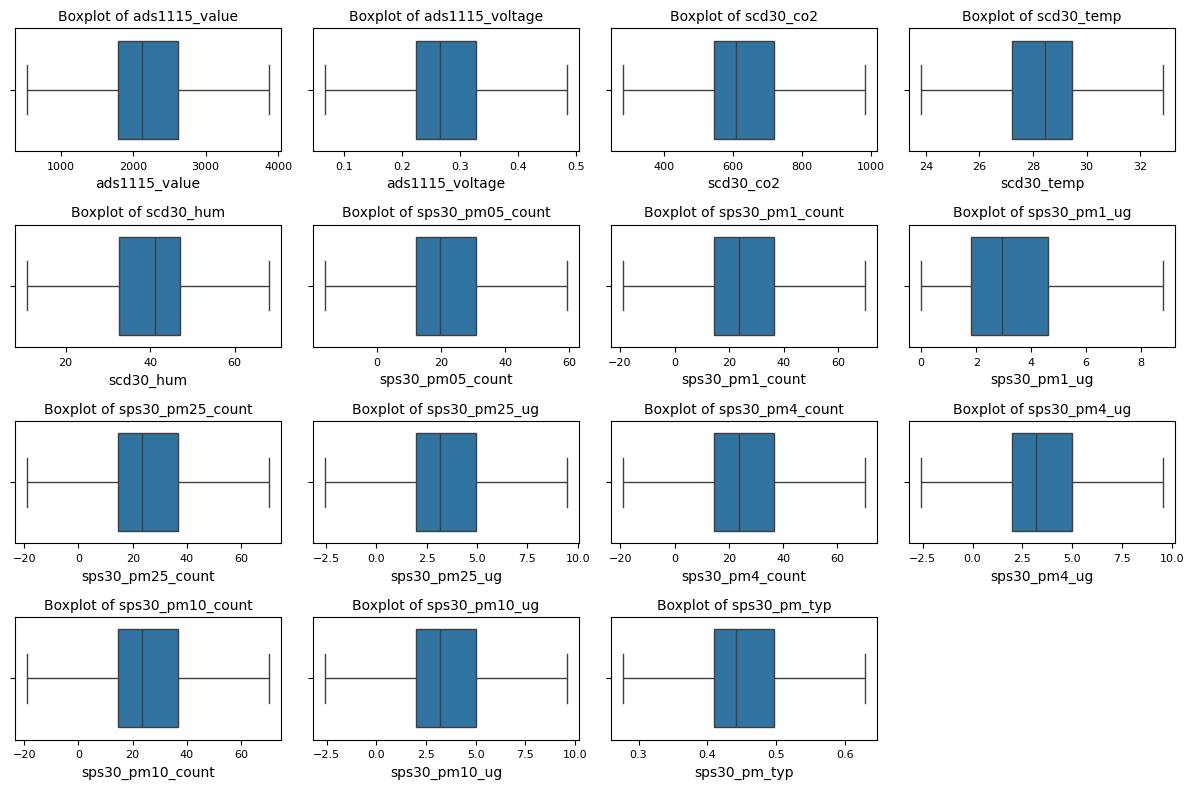

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler


numeric_cols = [col for col in numeric_cols if col not in ['brown', 'silver', 'gold']]

plt.figure(figsize=(12, 8))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4, 4, i)
    sns.boxplot(data=cleaned_data, x=col)
    plt.title(f"Boxplot of {col}", fontsize=10)
    plt.xticks(fontsize=8)

plt.subplots_adjust(hspace=0.6, wspace=0.4) #spacing each plot so they don't collide with one anohter

plt.tight_layout()
plt.show()

# Visualization of trends and relationships

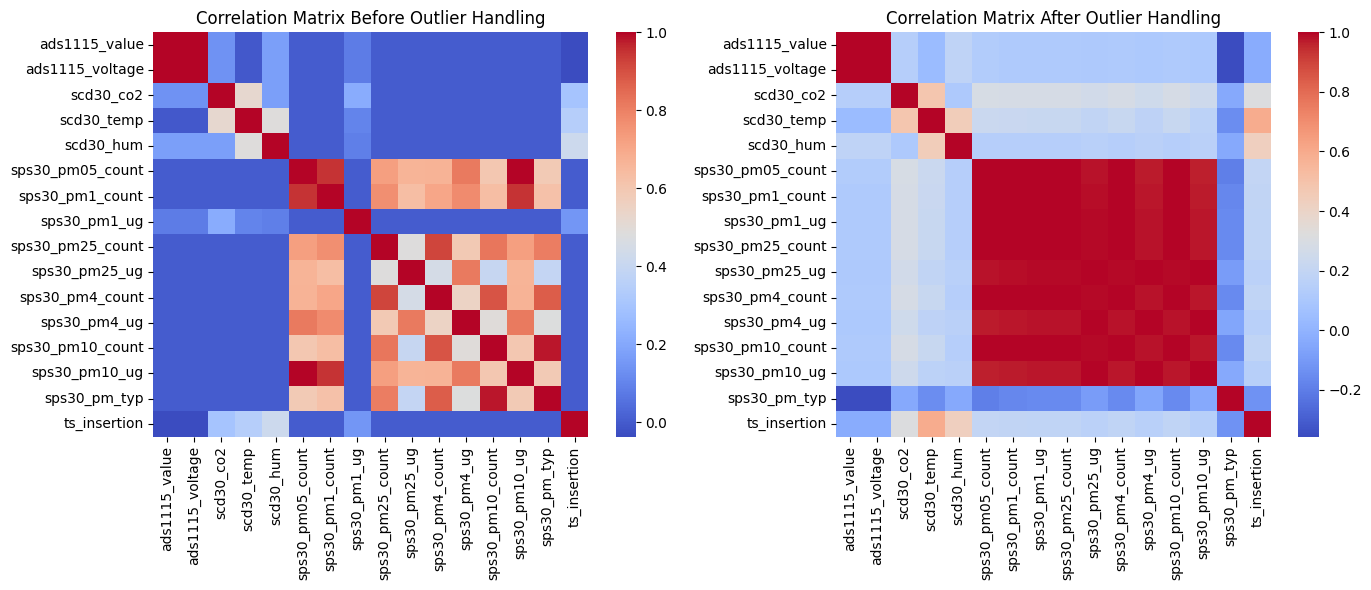

In [7]:
# @title Varsayılan başlık metni
columns_to_exclude = ['brown', 'silver', 'gold']
filtered_original = df.drop(columns=columns_to_exclude, errors='ignore')
filtered_cleaned = cleaned_data.drop(columns=columns_to_exclude, errors='ignore')

correlation_original = filtered_original.corr()
correlation_cleaned = filtered_cleaned.corr()

plt.figure(figsize=(14, 6))

#Original data correlation matrix
plt.subplot(1, 2, 1)
sns.heatmap(correlation_original, annot=False, cmap='coolwarm')
plt.title('Correlation Matrix Before Outlier Handling')

#Cleaned data correlation matrix
plt.subplot(1, 2, 2)
sns.heatmap(correlation_cleaned, annot=False, cmap='coolwarm')
plt.title('Correlation Matrix After Outlier Handling')

plt.tight_layout()
plt.show()

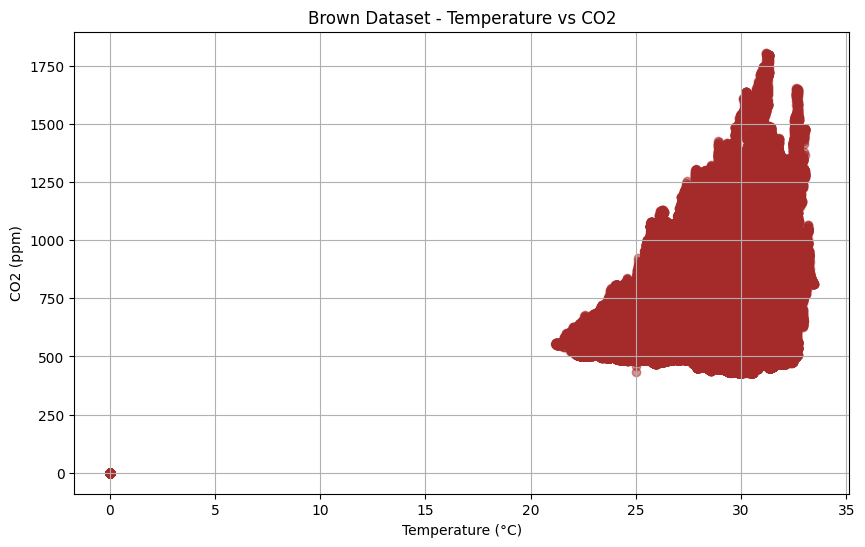

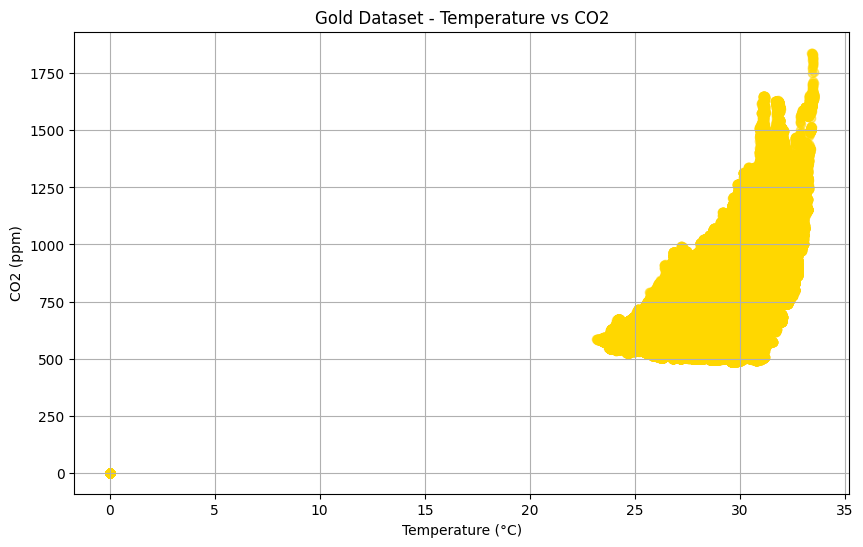

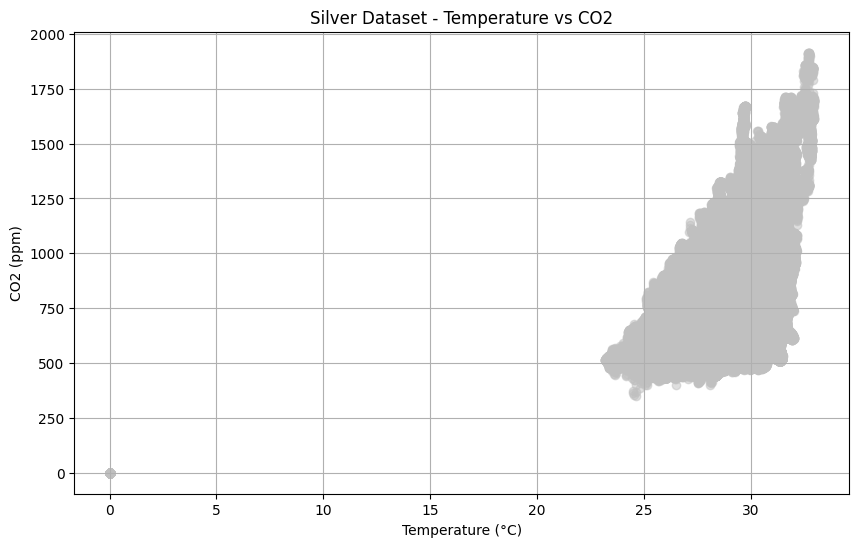

In [8]:
# @title Varsayılan başlık metni
import pandas as pd
import matplotlib.pyplot as plt

#Filtering
df_brown = df[df['brown'] == 1]
df_gold = df[df['gold'] == 1]
df_silver = df[df['silver'] == 1]

#Scatter plot for Brown data
plt.figure(figsize=(10, 6))
plt.scatter(df_brown['scd30_temp'], df_brown['scd30_co2'], color='brown', alpha=0.5)
plt.title('Brown Dataset - Temperature vs CO2')
plt.xlabel('Temperature (°C)')
plt.ylabel('CO2 (ppm)')
plt.grid(True)
plt.show()

#Scatter plot for Gold data
plt.figure(figsize=(10, 6))
plt.scatter(df_gold['scd30_temp'], df_gold['scd30_co2'], color='gold', alpha=0.5)
plt.title('Gold Dataset - Temperature vs CO2')
plt.xlabel('Temperature (°C)')
plt.ylabel('CO2 (ppm)')
plt.grid(True)
plt.show()

#Scatter plot for Silver data
plt.figure(figsize=(10, 6))
plt.scatter(df_silver['scd30_temp'], df_silver['scd30_co2'], color='silver', alpha=0.5)
plt.title('Silver Dataset - Temperature vs CO2')
plt.xlabel('Temperature (°C)')
plt.ylabel('CO2 (ppm)')
plt.grid(True)
plt.show()

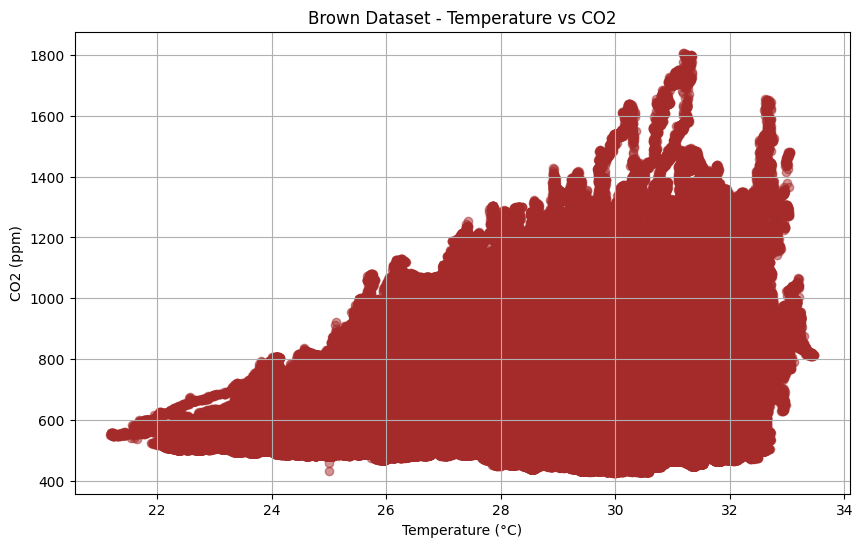

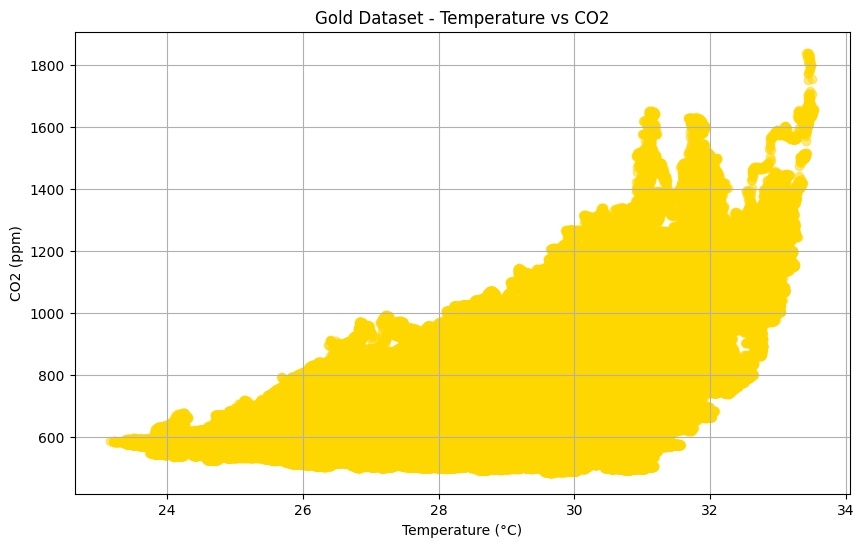

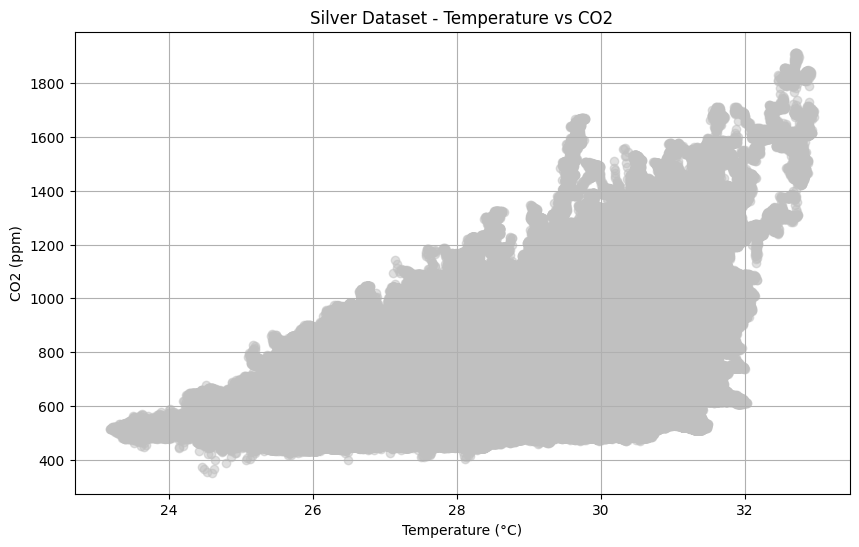

In [9]:
# @title Varsayılan başlık metni
# Assuming 'df' is already loaded and contains the columns 'brown', 'gold', 'silver', 'scd30_temp', and 'scd30_co2'

# Filter data for each category and restrict temperatures to the range 20-35
df_brown = df[(df['brown'] == 1) & (df['scd30_temp'] >= 20) & (df['scd30_temp'] <= 35)]
df_gold = df[(df['gold'] == 1) & (df['scd30_temp'] >= 20) & (df['scd30_temp'] <= 35)]
df_silver = df[(df['silver'] == 1) & (df['scd30_temp'] >= 20) & (df['scd30_temp'] <= 35)]

# Scatter plot for Brown data
plt.figure(figsize=(10, 6))
plt.scatter(df_brown['scd30_temp'], df_brown['scd30_co2'], color='brown', alpha=0.5)
plt.title('Brown Dataset - Temperature vs CO2')
plt.xlabel('Temperature (°C)')
plt.ylabel('CO2 (ppm)')
plt.grid(True)
plt.show()

# Scatter plot for Gold data
plt.figure(figsize=(10, 6))
plt.scatter(df_gold['scd30_temp'], df_gold['scd30_co2'], color='gold', alpha=0.5)
plt.title('Gold Dataset - Temperature vs CO2')
plt.xlabel('Temperature (°C)')
plt.ylabel('CO2 (ppm)')
plt.grid(True)
plt.show()

# Scatter plot for Silver data
plt.figure(figsize=(10, 6))
plt.scatter(df_silver['scd30_temp'], df_silver['scd30_co2'], color='silver', alpha=0.5)
plt.title('Silver Dataset - Temperature vs CO2')
plt.xlabel('Temperature (°C)')
plt.ylabel('CO2 (ppm)')
plt.grid(True)
plt.show()

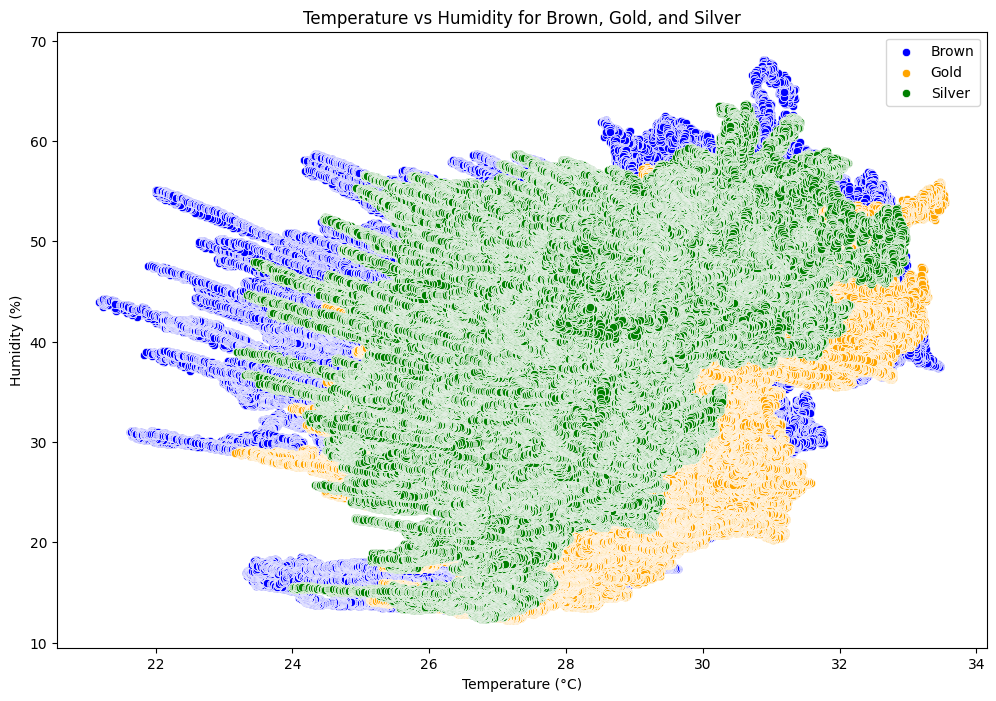

In [10]:
# @title Varsayılan başlık metni
filtered_data = df[(df['scd30_temp'] >= 20) & (df['scd30_temp'] <= 35)]

plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=filtered_data[filtered_data['brown'] == 1],
    x='scd30_temp',
    y='scd30_hum',
    label='Brown',
    color='blue'
)

sns.scatterplot(
    data=filtered_data[filtered_data['gold'] == 1],
    x='scd30_temp',
    y='scd30_hum',
    label='Gold',
    color='orange'
)

sns.scatterplot(
    data=filtered_data[filtered_data['silver'] == 1],
    x='scd30_temp',
    y='scd30_hum',
    label='Silver',
    color='green'
)

plt.title('Temperature vs Humidity for Brown, Gold, and Silver')
plt.xlabel('Temperature (°C)')
plt.ylabel('Humidity (%)')

plt.legend()
plt.show()

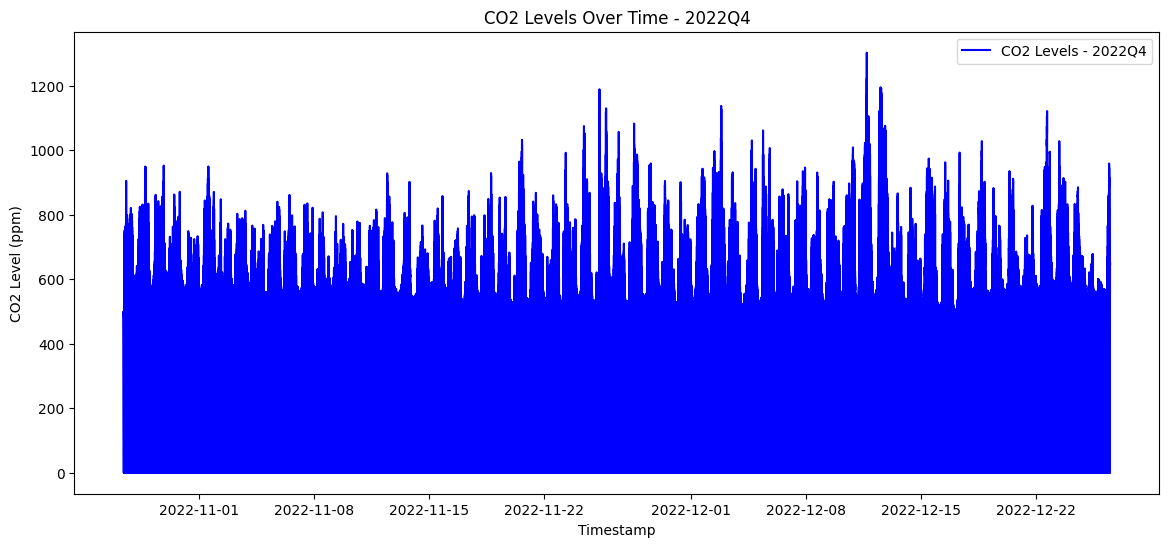

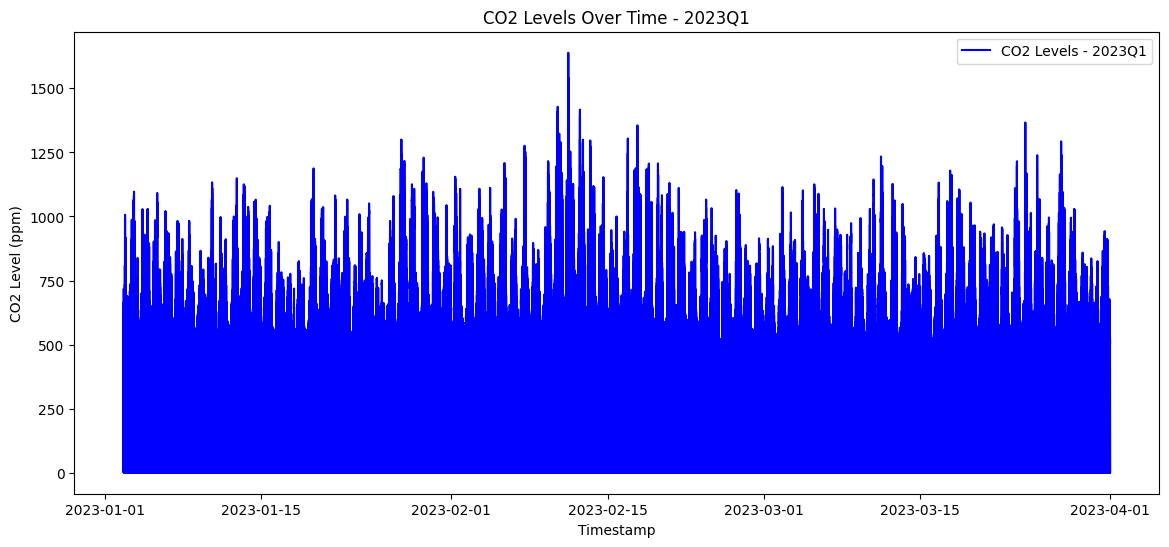

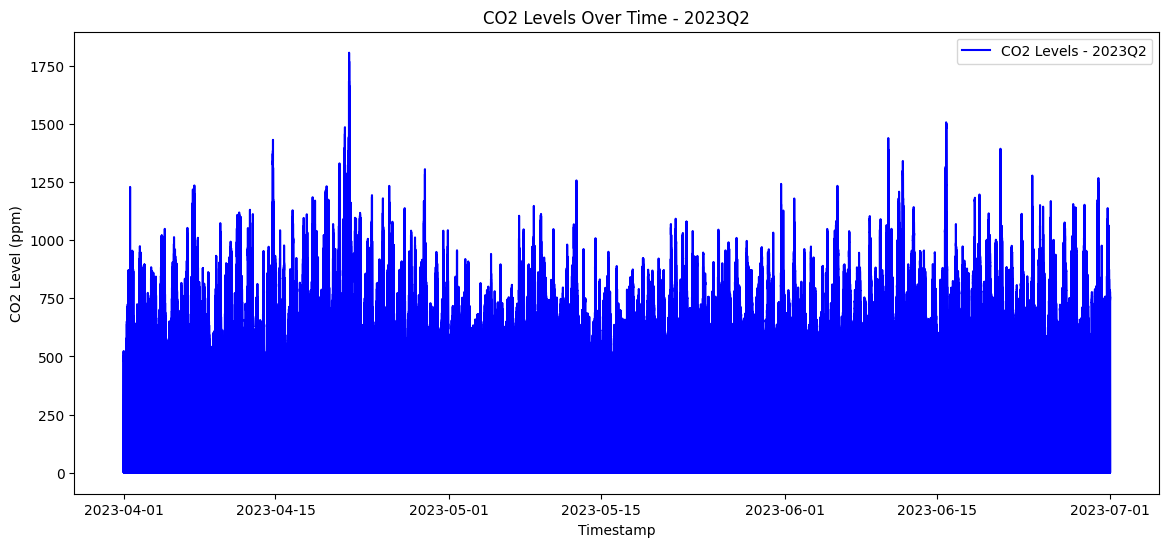

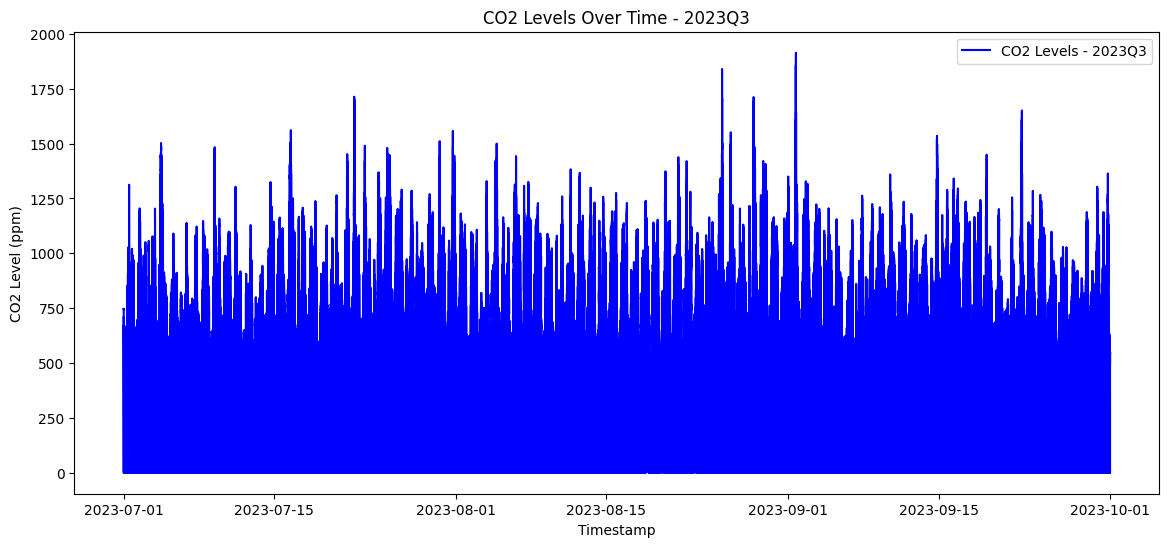

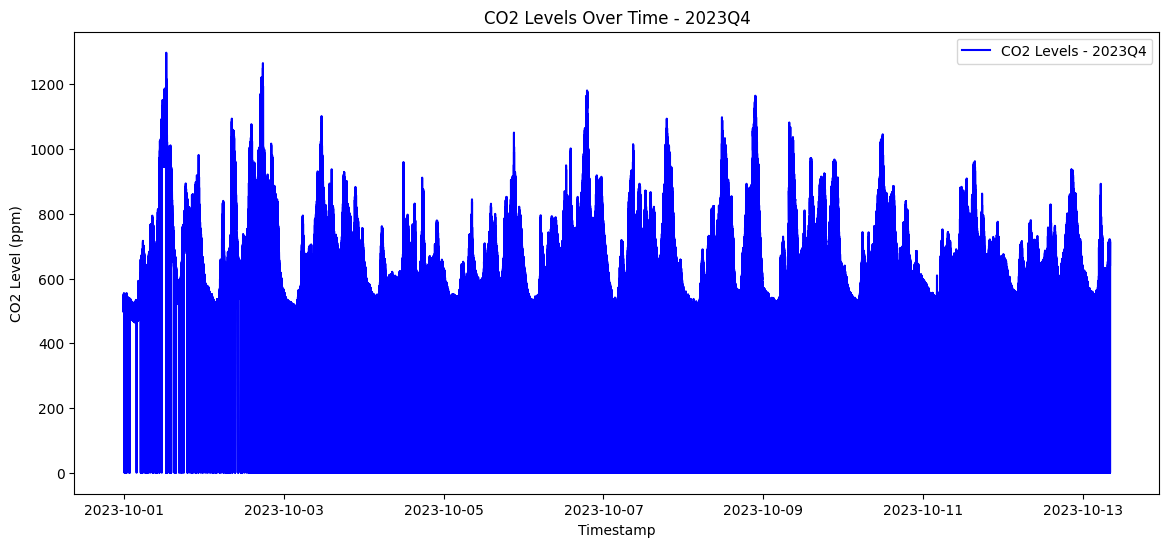

In [11]:
# @title Varsayılan başlık metni
cleaned_data['ts_insertion'] = pd.to_datetime(cleaned_data['ts_insertion'])
df_sorted = df.sort_values('ts_insertion')
df_sorted['quarter'] = df_sorted['ts_insertion'].dt.to_period('Q')
unique_quarters = df_sorted['quarter'].unique()

for quarter in unique_quarters:
    quarter_data = df_sorted[df_sorted['quarter'] == quarter]
    plt.figure(figsize=(14, 6))
    plt.plot(quarter_data['ts_insertion'], quarter_data['scd30_co2'], label=f'CO2 Levels - {quarter}', color='blue')
    plt.xlabel('Timestamp')
    plt.ylabel('CO2 Level (ppm)')
    plt.title(f'CO2 Levels Over Time - {quarter}')
    plt.legend()
    plt.show()

# Statistical Analysis

In [12]:
#Stratified sampling
brown_sample = df[df['brown'] == 1].groupby('sps30_pm_typ', group_keys=False).apply(lambda x: x.sample(frac=0.1))
gold_sample = df[df['gold'] == 1].groupby('sps30_pm_typ', group_keys=False).apply(lambda x: x.sample(frac=0.1))
silver_sample = df[df['silver'] == 1].groupby('sps30_pm_typ', group_keys=False).apply(lambda x: x.sample(frac=0.1))

print("Brown Sample CO2 Mean:", brown_sample['scd30_co2'].mean())
print("Gold Sample CO2 Mean:", gold_sample['scd30_co2'].mean())
print("Silver Sample CO2 Mean:", silver_sample['scd30_co2'].mean())

<ipython-input-12-e36ecbe07b57>:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  brown_sample = df[df['brown'] == 1].groupby('sps30_pm_typ', group_keys=False).apply(lambda x: x.sample(frac=0.1))
<ipython-input-12-e36ecbe07b57>:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gold_sample = df[df['gold'] == 1].groupby('sps30_pm_typ', group_keys=False).apply(lambda x: x.sample(frac=0.1))


Brown Sample CO2 Mean: 660.9049712181195
Gold Sample CO2 Mean: 660.1865997756003
Silver Sample CO2 Mean: 637.324444094503


<ipython-input-12-e36ecbe07b57>:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  silver_sample = df[df['silver'] == 1].groupby('sps30_pm_typ', group_keys=False).apply(lambda x: x.sample(frac=0.1))


In [13]:
#Cluster sampling
def cluster_sampling(df, number_of_clusters):
    try:
        cluster_size = len(df) // number_of_clusters
        remaining = len(df) % number_of_clusters
        cluster_ids = np.repeat(range(1, number_of_clusters + 1), cluster_size)         #creating the cluster_id column
        cluster_ids = np.concatenate([cluster_ids, np.repeat(range(1, remaining + 1), 1)])

        np.random.shuffle(cluster_ids)
        df['cluster_id'] = cluster_ids

        indexes = df[df['cluster_id'] % 2 == 0].index

        cluster_sample = df.loc[indexes]
        return cluster_sample
    except Exception as e:
        print(f"An error occurred: {e}")
        return pd.DataFrame()

cluster_sample = cluster_sampling(df, 5)

if cluster_sample.empty:
    print("No valid cluster sample was created.")
else:
    print("Cluster Sample CO2 Mean:", cluster_sample['scd30_co2'].mean())

Cluster Sample CO2 Mean: 647.1001257138787


In [14]:
from scipy.stats import f_oneway

brown_group = df[df['brown'] == 1]['scd30_co2']
gold_group = df[df['gold'] == 1]['scd30_co2']
silver_group = df[df['silver'] == 1]['scd30_co2']

#ANOVA
f_stat, p_value = f_oneway(brown_group, gold_group, silver_group)

print("F-Statistic:", f_stat)
print("P-Value:", p_value)

if p_value < 0.05:
    print("There is a statistically significant difference between the groups.")
else:
    print("There is no statistically significant difference between the groups.")

F-Statistic: 80501.23348505184
P-Value: 0.0
There is a statistically significant difference between the groups.


In [15]:
from random import sample

co2_list = list(df[df['gold'] == 1]['scd30_co2'])

#simple random sampling (500 samples)
sample_co2 = sample(co2_list, 500)

print("Simple Random Sample CO2 Mean:", sum(sample_co2) / len(sample_co2))

Simple Random Sample CO2 Mean: 664.247054


In [16]:
df

,ads1115_value,ads1115_voltage,scd30_co2,scd30_temp,scd30_hum,sps30_pm05_count,sps30_pm1_count,sps30_pm1_ug,sps30_pm25_count,sps30_pm25_ug,sps30_pm4_count,sps30_pm4_ug,sps30_pm10_count,sps30_pm10_ug,sps30_pm_typ,ts_insertion,brown,gold,silver,cluster_id
0,2015.0,0.251883,659.087,29.3526,51.7715,43.0549,50.3810,6.32602,50.4870,6.68953,50.4978,6.68954,50.5058,6.68954,0.424354,2022-10-27 10:57:14,1.0,0.0,0.0,2
1,1950.0,0.243757,658.184,29.3660,51.7990,43.5107,50.9143,6.39299,51.0214,6.76034,51.0324,6.76035,51.0405,6.76035,0.427185,2022-10-27 10:57:17,1.0,0.0,0.0,5
2,1995.0,0.249133,655.991,29.3927,51.8387,44.1547,51.6679,6.48762,51.7767,6.86041,51.7878,6.86042,51.7960,6.86041,0.428009,2022-10-27 10:57:19,1.0,0.0,0.0,3
3,2010.0,0.251258,655.740,29.3526,51.8906,44.2329,51.7594,6.49910,51.8683,6.87255,51.8794,6.87256,51.8877,6.87256,0.426949,2022-10-27 10:57:21,1.0,0.0,0.0,2
4,1993.0,0.249133,655.774,29.3660,51.8448,44.4443,52.0068,6.53017,52.1163,6.90541,52.1274,6.90541,52.1357,6.90541,0.428101,2022-10-27 10:57:23,1.0,0.0,0.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28177931,1663.0,0.207881,713.675,28.1483,43.4067,38.6570,46.0142,5.80072,46.2946,6.13404,46.3085,6.13405,46.3175,6.13405,0.540815,2023-10-13 08:04:12,0.0,1.0,0.0,4
28177932,1664.0,0.208006,713.536,28.1483,43.3792,39.3510,46.8404,5.90487,47.1258,6.24418,47.1399,6.24418,47.1491,6.24418,0.540534,2023-10-13 08:04:14,0.0,1.0,0.0,3
28177933,1645.0,0.205631,713.131,28.1617,43.3243,39.4641,46.9749,5.92183,47.2612,6.26211,47.2754,6.26212,47.2845,6.26212,0.544188,2023-10-13 08:04:17,0.0,1.0,0.0,4
28177934,1664.0,0.207881,711.359,28.1617,43.3655,39.8152,47.3929,5.97452,47.6817,6.31783,47.6960,6.31783,47.7052,6.31783,0.543882,2023-10-13 08:04:19,0.0,1.0,0.0,2


# air quality

In [88]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Create a new DataFrame for air quality parameters
air_quality_df = cleaned_data[
    [
        "ads1115_value", "sps30_pm25_ug", "sps30_pm10_ug",
        "scd30_temp", "scd30_hum", "scd30_co2","ts_insertion"
    ]
].dropna()

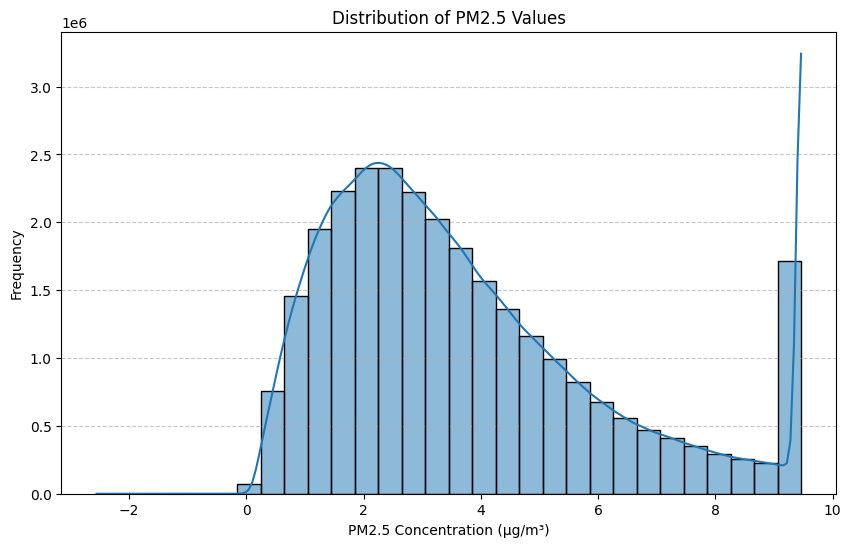

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check if 'sps30_pm25_ug' exists in the dataset and plot its distribution
if 'sps30_pm25_ug' in cleaned_data.columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(cleaned_data['sps30_pm25_ug'].dropna(), bins=30, kde=True)
    plt.title('Distribution of PM2.5 Values')
    plt.xlabel('PM2.5 Concentration (µg/m³)')
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
else:
    print("Column 'sps30_pm25_ug' is not available in the dataset.")

In [78]:
def calculate_aqi_auto(c, pollutant):
    """
    Calculate AQI and its status based on pollutant concentration (c) and pollutant type.
    c: Pollutant concentration
    pollutant: Type of pollutant (e.g., "PM2.5", "PM10", "O3")
    """
    # Define breakpoint tables for different pollutants
    breakpoints = {
        "PM2.5": [
            (0.0, 12.0, 0, 50),
            (12.1, 35.4, 51, 100),
            (35.5, 55.4, 101, 150),
            (55.5, 150.4, 151, 200),
            (150.5, 250.4, 201, 300),
            (250.5, 500.4, 301, 500),
        ],
        "PM10": [
            (0.0, 54.0, 0, 50),
            (55.0, 154.0, 51, 100),
            (155.0, 254.0, 101, 150),
            (255.0, 354.0, 151, 200),
            (355.0, 424.0, 201, 300),
            (425.0, 604.0, 301, 500),
        ]
    }

    # Select the appropriate breakpoints for the pollutant
    if pollutant not in breakpoints:
        raise ValueError(f"Unsupported pollutant type: {pollutant}")

    pollutant_breakpoints = breakpoints[pollutant]

    # Find the correct breakpoint range
    for c_low, c_high, i_low, i_high in pollutant_breakpoints:
        if c_low <= c <= c_high:
            # Calculate AQI using the formula
            aqi = ((i_high - i_low) / (c_high - c_low)) * (c - c_low) + i_low
            aqi = round(aqi)

            # Determine AQI status
            if aqi <= 50:
                status = "Good"
            elif 51 <= aqi <= 100:
                status = "Moderate"
            elif 101 <= aqi <= 150:
                status = "Unhealthy for Sensitive Groups"
            elif 151 <= aqi <= 200:
                status = "Unhealthy"
            elif 201 <= aqi <= 300:
                status = "Very Unhealthy"
            else:
                status = "Hazardous"

            return aqi, status

    # If no range matches, return error
    raise ValueError(f"Concentration {c} is out of range for pollutant {pollutant}.")

air_quality_df["sps30_pm25_ug"] = air_quality_df["sps30_pm25_ug"].apply(lambda x: max(x, 0))
air_quality_df["sps30_pm10_ug"] = air_quality_df["sps30_pm10_ug"].apply(lambda x: max(x, 0))

air_quality_df["aqi_pm25"] = air_quality_df["sps30_pm25_ug"].apply(lambda x: calculate_aqi_auto(x, "PM2.5")[0])
air_quality_df["aqi_pm10"] = air_quality_df["sps30_pm10_ug"].apply(lambda x: calculate_aqi_auto(x, "PM10")[0])


In [68]:
air_quality_df.describe()

,ads1115_value,sps30_pm25_ug,sps30_pm10_ug,scd30_temp,scd30_hum,aqi_pm25,aqi_pm10
count,2.817794e+07,2.817794e+07,2.817794e+07,2.817794e+07,2.817794e+07,2.817794e+07,2.817794e+07
mean,2.204150e+03,3.736028e+00,3.796829e+00,2.832204e+01,3.949505e+01,1.554383e+01,3.523240e+00
std,5.132611e+02,2.376660e+00,2.423764e+00,1.562056e+00,9.473063e+00,9.851525e+00,2.279243e+00
min,5.360000e+02,0.000000e+00,0.000000e+00,2.382625e+01,1.088105e+01,0.000000e+00,0.000000e+00
25%,1.787000e+03,1.950600e+00,1.978660e+00,2.721100e+01,3.266600e+01,8.000000e+00,2.000000e+00
50%,2.123000e+03,3.167400e+00,3.209920e+00,2.845810e+01,4.110110e+01,1.300000e+01,3.000000e+00
75%,2.621000e+03,4.955090e+00,5.022340e+00,2.946750e+01,4.718930e+01,2.100000e+01,5.000000e+00
max,3.872000e+03,9.461825e+00,9.587860e+00,3.285225e+01,6.809080e+01,3.900000e+01,9.000000e+00


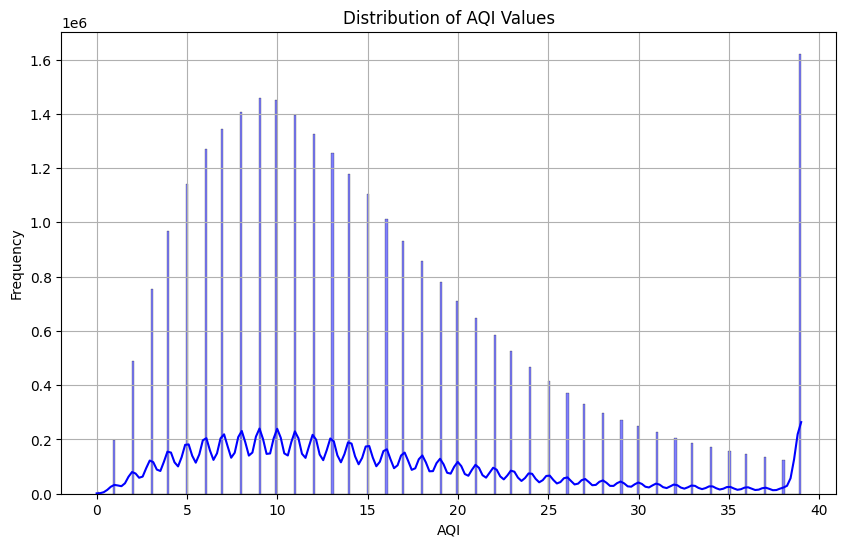

In [69]:
plt.figure(figsize=(10, 6))
sns.histplot(air_quality_df["aqi_pm25"], bins=300, kde=True, color="blue")
plt.title("Distribution of AQI Values")
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

In [83]:
# Ensure 'ts_insertion' is in datetime format
air_quality_df['ts_insertion'] = pd.to_datetime(air_quality_df['ts_insertion'])

# Extract month and year for grouping
air_quality_df['year_month'] = air_quality_df['ts_insertion'].dt.to_period('M')

# Calculate the monthly average AQI
monthly_aqi = air_quality_df.groupby('year_month')['aqi_pm25'].mean().reset_index()

# Convert 'year_month' back to a datetime format for plotting
monthly_aqi['year_month'] = monthly_aqi['year_month'].dt.to_timestamp()

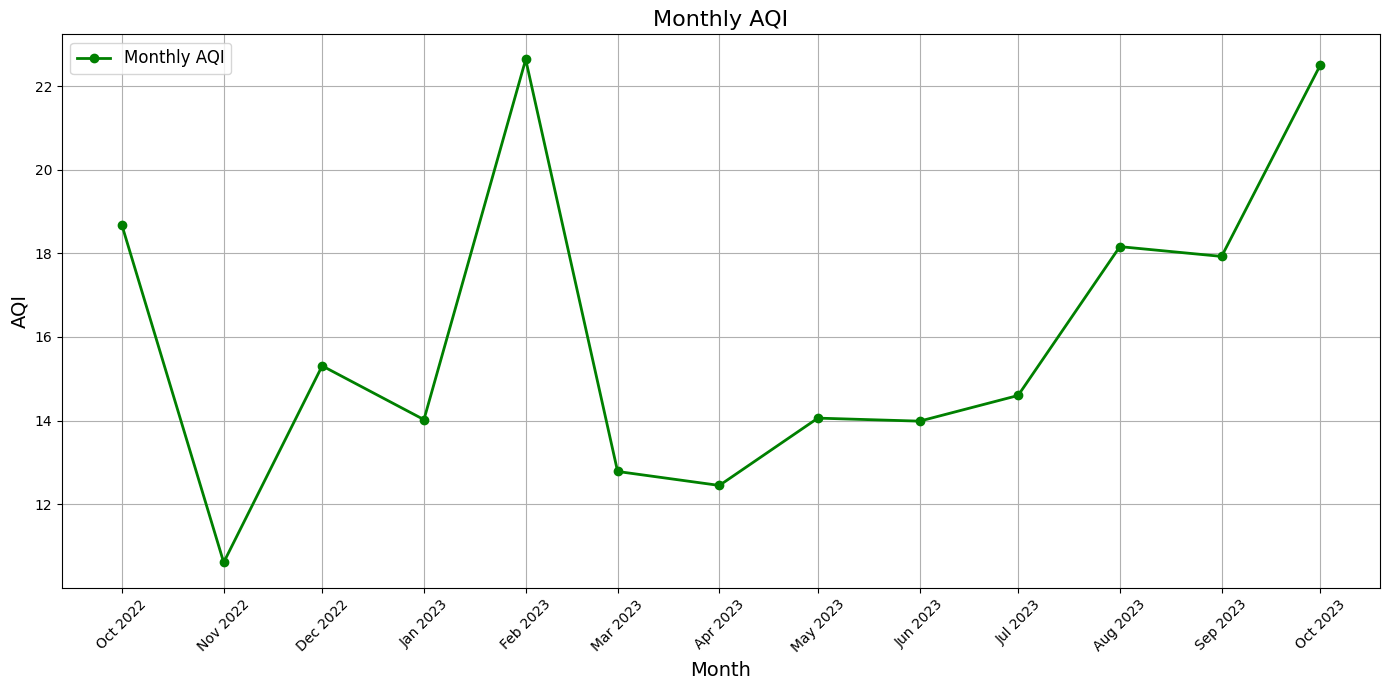

In [86]:
import matplotlib.dates as mdates
plt.figure(figsize=(14, 7))
plt.plot(monthly_aqi['year_month'], monthly_aqi['aqi_pm25'], label='Monthly AQI', color='green', marker='o', linewidth=2)

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))  # Set x-axis ticks for every month
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.title('Monthly AQI', fontsize=16)
plt.xlabel('Month', fontsize=14)
plt.ylabel('AQI', fontsize=14)
plt.grid(True)
plt.legend(fontsize=12)
plt.xticks(rotation=45)  # Rotate tick labels for better readability
plt.tight_layout()
plt.show()

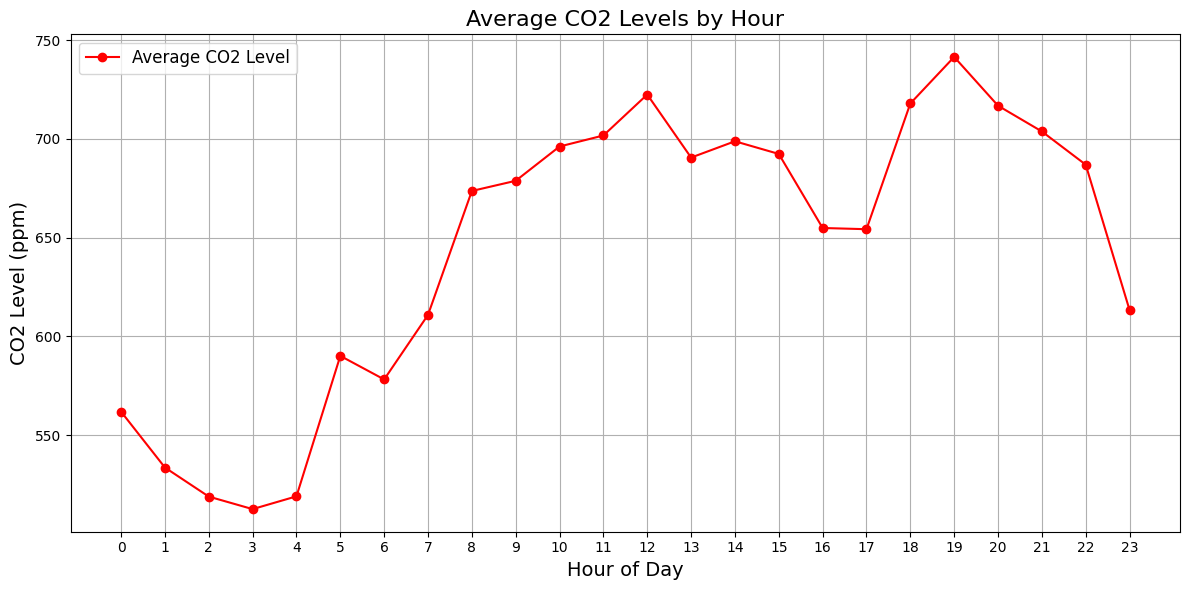

In [105]:
# Extract the hour from the timestamp
air_quality_df['hour'] = air_quality_df['ts_insertion'].dt.hour

# Calculate the average CO2 levels for each hour
hourly_co2 = air_quality_df.groupby('hour')['scd30_co2'].mean().reset_index()


# Plot CO2 levels based on hours
plt.figure(figsize=(12, 6))
plt.plot(hourly_co2['hour'], hourly_co2['scd30_co2'], marker='o', color='red', label='Average CO2 Level')
plt.title('Average CO2 Levels by Hour', fontsize=16)
plt.xlabel('Hour of Day', fontsize=14)
plt.ylabel('CO2 Level (ppm)', fontsize=14)
plt.grid(True)
plt.xticks(range(0, 24))  # Set x-axis ticks for each hour
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()